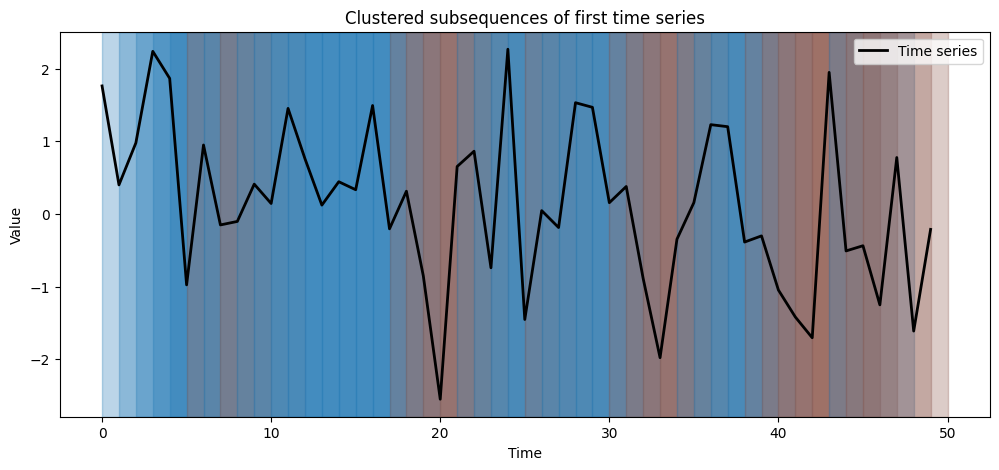

[0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 0
 0 1 1 1 1 1 0 1 1]


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Generating synthetic time series data
np.random.seed(0)
time_series_data = np.random.randn(10, 50)  # 10 time series, each of length 50

# Extracting subsequences
window_size = 5
subsequences = [time_series_data[i, j:j+window_size] 
                for i in range(time_series_data.shape[0]) 
                for j in range(time_series_data.shape[1] - window_size + 1)]
subsequences = np.array(subsequences)

# Standardizing the subsequences
scaler = StandardScaler()
subsequences_scaled = scaler.fit_transform(subsequences)

# Clustering using k-Means
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(subsequences_scaled)

# Labels for the first time series
first_ts_labels = labels[:time_series_data.shape[1] - window_size + 1]

# Plotting the first time series
plt.figure(figsize=(12, 5))
plt.plot(time_series_data[0], color="black", linewidth=2, label="Time series")

# Overlay cluster segments
colors = plt.cm.tab10(np.linspace(0, 1, 3))
for i, cluster_id in enumerate(first_ts_labels):
    plt.axvspan(i, i + window_size, color=colors[cluster_id], alpha=0.3)

plt.title("Clustered subsequences of first time series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()
print(first_ts_labels)
